In [1]:
try:
    import keras
    import tensorflow
except:
    %pip install keras_preprocessing
    %pip install keras -qqq
    %pip install tensorflow -qqq
    %pip install pyserial -qqq
    %pip install matplotlib -qqq
    import keras
    import tensorflow
    import serial

2026-01-09 00:31:26.490875: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 00:31:26.493987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 00:31:26.662075: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 00:31:27.848614: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import random as rd


In [3]:
import serial
serial.Serial()

Serial<id=0x7ff928748d90, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)

In [4]:
%pip install pyserial -qqq


Note: you may need to restart the kernel to use updated packages.


In [5]:
from keras_preprocessing import image as img

In [6]:
from PIL import Image

In [7]:
import socket
import numpy as np
import matplotlib.pyplot as plt
import struct

In [8]:
path_port_serial = "/dev/ttyUSB1"
baudrate = 115200

## Conjunto de funções dedicadas a comunicação TCP/IP - FreeRTOS

In [9]:
def connect_to_server(server_ip, server_port,string):
    """Establishes a connection to the server and returns the socket."""
    client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client_socket.connect((server_ip, server_port))
    print(f"Connected to server at {server_ip}:{server_port} - {string}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return client_socket
def send_message(client_socket, data):
    """Sends raw data to the server."""
    client_socket.sendall(data)

def receive_message(client_socket, data_size):
    """Receives raw data from the server."""
    data = client_socket.recv(data_size)  # Receive the data of the specified size
    #print("Received data.")
    return data

In [10]:
def plot_data(sent_data, received_data):
    """Plots the sent and received data with customizations."""
    plt.figure(figsize=(10, 5))
    
    # Set background color to black
    plt.gcf().set_facecolor('black')
    
    # Plot the sent data
    plt.subplot(2, 1, 1)
    plt.title("Sent Sine Wave Data", color='white')
    plt.stem(sent_data)  # Thicker cyan line for sent data
    plt.grid(True, color='white')  # White grid lines
    plt.tick_params(axis='both', colors='white')  # White ticks

    # Plot the received data
    plt.subplot(2, 1, 2)
    plt.title("Received Signal Data", color='white')
    plt.stem(received_data)  # Thicker red line for received data
    plt.grid(True, color='white')  # White grid lines
    plt.tick_params(axis='both', colors='white')  # White ticks

    plt.tight_layout()
    plt.show()


In [11]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [12]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
  return [Ain,Bin]

In [13]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [14]:
def send_matrix_rec(X,input,fs_pc2fpga_rate):
  file = open(f"teste{input}.txt","+w")
   
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = baudrate
  s.bytesize = 8

  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    conc = 0
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      conc += X[j][i]*pow(10,j)
      time.sleep(1/fs_pc2fpga_rate)
    if(fs_pc2fpga_rate <10):
      strr = str(conc)[::-1]
      print(f'{strr}',"\n")
  s.write(bytearray([0xad]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xda]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

### Problemas observados FIFO perda de dados ao aumentar a taxa de transmissão, GPIO não possui informação a respeito de quando foi escrito ou lido um determinado valor]

In [15]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    #s.timeout = .5#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    a = s.read()
    print(a)
    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        try:
            a = s.read()[0]
        except IndexError:
            print("Matriz corrompida...")
            return Y
        if(a==b''):
            print("Vazio")
            return Y
        if(a!=0 and a!=254 and a!=239 and a!= 255):

            i+=1
            Y[index_row][index_col] = a
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [16]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [17]:
def transmitter_uart(M,fs_pc2fpga_rate):
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M_p)
    send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate)
    send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate)

In [18]:

delay = 1/1000
def send1(Asyst,delay = 1/1000):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    print("Connection closed.")
           
    client_socket.close()

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [19]:
#A,B = np.array(create_matrix(3,1))
#Asyst ,Bsyst = shiftMatrixSystolic(A,B)
#send1(Asyst,delay = 1)
#send(Bsyst,delay = 5)

In [20]:


def send2(Asyst,delay = 1/1000):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = bytearray(data_vec)
    send_message(client_socket, data_vec_bytes)
    print(data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = bytearray(data_vec)
    send_message(client_socket, data_vec_bytes)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
            time.sleep(delay)
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            data_vec_bytes = bytearray(data_vec)
            send_message(client_socket, data_vec_bytes)
            print("index: ",i, i+j*16,",", "Data: ",data_vec)
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        print(strr)
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = bytearray(data_vec)
    print(data_vec_bytes)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = bytearray(data_vec)

    send_message(client_socket, data_vec_bytes)
    print("Connection closed.")
           
    #client_socket.close()

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [21]:
#A,B = np.array(create_matrix(16,1))
#Asyst ,Bsyst = shiftMatrixSystolic(A,B)
#send2(Asyst,delay = 1/1000)

In [22]:


def send(Asyst,delay = 1/1000,k=500):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+1}) = 0xff;")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+2}) = 0xff;")

    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #client_socket.close()
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
           
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
           
     #       send_message(client_socket, data_vec_bytes)
            
            print(f"*(SourceAddr + {k+3}) = {data_vec[0]};")
            
        #print("index: ",i, k,",", "Data: ",data_vec)
            k+=1
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        

      #  print(strr)
        #time.sleep(2)
    #data_vec = [0xad]
    #data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #time.sleep(delay)
    #client_socket.close()
    ## Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    time.sleep(delay)
    data_vec = [0xad]
    print(f"*(SourceAddr + {k+3}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    print(f"*(SourceAddr + {k+4}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
#    send_message(client_socket, data_vec_bytes)
    #client_socket.close()


In [23]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
*(SourceAddr + 501) = 0xff;
*(SourceAddr + 502) = 0xff;
*(SourceAddr + 503) = 0;
*(SourceAddr + 504) = 0;
*(SourceAddr + 505) = 0;
*(SourceAddr + 506) = 0;
*(SourceAddr + 507) = 0;
*(SourceAddr + 508) = 0;
*(SourceAddr + 509) = 0;
*(SourceAddr + 510) = 0;
*(SourceAddr + 511) = 0;
*(SourceAddr + 512) = 0;
*(SourceAddr + 513) = 0;
*(SourceAddr + 514) = 0;
*(SourceAddr + 515) = 0;
*(SourceAddr + 516) = 0;
*(SourceAddr + 517) = 0;
*(SourceAddr + 518) = 2;
*(SourceAddr + 519) = 0;
*(SourceAddr + 520) = 0;
*(SourceAddr + 521) = 0;
*(SourceAddr + 522) = 0;
*(SourceAddr + 523) = 0;
*(SourceAddr + 524) = 0;
*(SourceAddr + 525) = 0;
*(SourceAddr + 526) = 0;
*(SourceAddr + 527) = 0;
*(SourceAddr + 528) = 0;
*(SourceAddr + 529) = 0;
*(SourceAddr + 530) = 0;
*(SourceAddr + 531) = 0;
*(SourceAddr + 532) = 0;
*(SourceAddr + 533) = 1;
*(SourceAddr + 534) = 2;
*(SourceAddr + 535) = 0;
*(SourceAddr + 536) = 0;
*(SourceAddr + 537) = 0;
*(SourceAd

Aaa=array([[4, 3, 3, 2, 2, 1, 3, 2, 1, 2, 4, 4, 2, 3, 2, 2],
       [4, 3, 1, 2, 3, 3, 1, 2, 1, 4, 2, 1, 4, 3, 4, 3],
       [4, 2, 1, 3, 1, 3, 1, 2, 4, 4, 4, 3, 1, 3, 2, 1],
       [1, 4, 3, 1, 2, 3, 1, 3, 2, 1, 4, 2, 1, 2, 4, 2],
       [4, 4, 2, 2, 3, 1, 1, 4, 3, 3, 2, 1, 2, 3, 2, 4],
       [4, 4, 2, 1, 4, 1, 1, 4, 3, 2, 4, 1, 3, 2, 1, 1],
       [2, 4, 4, 2, 2, 3, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1],
       [1, 2, 4, 2, 1, 3, 2, 1, 2, 3, 2, 1, 3, 3, 4, 2],
       [2, 3, 1, 2, 4, 2, 1, 2, 1, 1, 2, 1, 2, 3, 2, 1],
       [1, 2, 3, 3, 2, 2, 4, 3, 3, 4, 4, 4, 3, 3, 2, 2],
       [3, 4, 1, 3, 4, 4, 3, 2, 3, 3, 3, 4, 1, 2, 1, 3],
       [3, 4, 2, 3, 4, 3, 1, 1, 4, 1, 1, 1, 2, 2, 4, 1],
       [1, 4, 3, 2, 4, 2, 4, 3, 4, 3, 4, 1, 2, 4, 4, 3],
       [2, 2, 2, 2, 3, 4, 3, 1, 1, 3, 3, 3, 4, 4, 1, 1],
       [3, 1, 3, 1, 4, 2, 1, 1, 4, 1, 1, 4, 3, 3, 3, 3],
       [3, 4, 2, 3, 3, 1, 4, 4, 3, 1, 2, 4, 1, 4, 3, 3]])

 Bbb=      array([[4, 4, 3, 2, 4, 4, 1, 1, 1, 4, 1, 2, 3, 4, 4, 1],
       [2, 4, 1, 2, 2, 4, 1, 2, 4, 4, 4, 3, 4, 2, 4, 3],
       [1, 4, 4, 4, 3, 2, 4, 4, 1, 3, 1, 1, 2, 3, 2, 3],
       [4, 2, 2, 3, 4, 4, 1, 1, 1, 1, 1, 1, 2, 3, 4, 3],
       [2, 3, 4, 3, 1, 4, 2, 4, 4, 3, 3, 2, 4, 2, 2, 3],
       [1, 4, 1, 4, 3, 4, 4, 2, 4, 2, 2, 2, 3, 4, 4, 3],
       [4, 3, 4, 2, 4, 4, 3, 3, 2, 3, 2, 4, 2, 1, 3, 2],
       [1, 2, 1, 2, 3, 4, 2, 2, 3, 1, 4, 3, 3, 2, 2, 1],
       [4, 3, 4, 4, 3, 3, 4, 2, 2, 4, 2, 2, 1, 2, 1, 4],
       [3, 1, 4, 2, 4, 1, 4, 4, 4, 3, 3, 4, 3, 1, 3, 2],
       [1, 4, 3, 2, 3, 4, 1, 3, 4, 2, 2, 1, 4, 4, 2, 1],
       [2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 4, 3, 2, 4, 4, 4],
       [4, 2, 1, 3, 4, 1, 1, 1, 2, 3, 3, 1, 2, 2, 3, 2],
       [2, 4, 1, 1, 2, 4, 4, 4, 2, 4, 3, 1, 4, 1, 4, 4],
       [2, 1, 4, 4, 1, 3, 4, 1, 3, 1, 3, 3, 4, 1, 1, 3],
       [2, 4, 1, 3, 3, 1, 3, 2, 2, 1, 1, 4, 2, 3, 4, 2]])

In [24]:


def send_debug(Asyst,delay = 1/1000,k=500):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+1}) = 0xff;")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    print(f"*(SourceAddr + {k+2}) = 0xff;")

    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #client_socket.close()
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)

    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
           
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
           
     #       send_message(client_socket, data_vec_bytes)
            
            print(f"*(SourceAddr + {k+3}) = {data_vec[0]};")
            
        #print("index: ",i, k,",", "Data: ",data_vec)
            k+=1
           # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            # Receive the response (assuming the server sends 32-bit integers)
            #raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            # Plot the sent and received data
            #plot_data(data_vec, received_data)
            # Close the connection
        

        #print(strr)
        #time.sleep(2)
    #data_vec = [0xad]
    #data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    #time.sleep(delay)
    #client_socket.close()
    ## Connect to the server
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    time.sleep(delay)
    data_vec = [0xad]
    print(f"*(SourceAddr + {k+3}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    #send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    print(f"*(SourceAddr + {k+4}) = {0xad};")
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
#    send_message(client_socket, data_vec_bytes)
    #client_socket.close()


In [25]:
Aaa=np.array([[4, 3, 3, 2, 2, 1, 3, 2, 1, 2, 4, 4, 2, 3, 2, 2],
       [4, 3, 1, 2, 3, 3, 1, 2, 1, 4, 2, 1, 4, 3, 4, 3],
       [4, 2, 1, 3, 1, 3, 1, 2, 4, 4, 4, 3, 1, 3, 2, 1],
       [1, 4, 3, 1, 2, 3, 1, 3, 2, 1, 4, 2, 1, 2, 4, 2],
       [4, 4, 2, 2, 3, 1, 1, 4, 3, 3, 2, 1, 2, 3, 2, 4],
       [4, 4, 2, 1, 4, 1, 1, 4, 3, 2, 4, 1, 3, 2, 1, 1],
       [2, 4, 4, 2, 2, 3, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1],
       [1, 2, 4, 2, 1, 3, 2, 1, 2, 3, 2, 1, 3, 3, 4, 2],
       [2, 3, 1, 2, 4, 2, 1, 2, 1, 1, 2, 1, 2, 3, 2, 1],
       [1, 2, 3, 3, 2, 2, 4, 3, 3, 4, 4, 4, 3, 3, 2, 2],
       [3, 4, 1, 3, 4, 4, 3, 2, 3, 3, 3, 4, 1, 2, 1, 3],
       [3, 4, 2, 3, 4, 3, 1, 1, 4, 1, 1, 1, 2, 2, 4, 1],
       [1, 4, 3, 2, 4, 2, 4, 3, 4, 3, 4, 1, 2, 4, 4, 3],
       [2, 2, 2, 2, 3, 4, 3, 1, 1, 3, 3, 3, 4, 4, 1, 1],
       [3, 1, 3, 1, 4, 2, 1, 1, 4, 1, 1, 4, 3, 3, 3, 3],
       [3, 4, 2, 3, 3, 1, 4, 4, 3, 1, 2, 4, 1, 4, 3, 3]])

Bbb=      np.array([[4, 4, 3, 2, 4, 4, 1, 1, 1, 4, 1, 2, 3, 4, 4, 1],
       [2, 4, 1, 2, 2, 4, 1, 2, 4, 4, 4, 3, 4, 2, 4, 3],
       [1, 4, 4, 4, 3, 2, 4, 4, 1, 3, 1, 1, 2, 3, 2, 3],
       [4, 2, 2, 3, 4, 4, 1, 1, 1, 1, 1, 1, 2, 3, 4, 3],
       [2, 3, 4, 3, 1, 4, 2, 4, 4, 3, 3, 2, 4, 2, 2, 3],
       [1, 4, 1, 4, 3, 4, 4, 2, 4, 2, 2, 2, 3, 4, 4, 3],
       [4, 3, 4, 2, 4, 4, 3, 3, 2, 3, 2, 4, 2, 1, 3, 2],
       [1, 2, 1, 2, 3, 4, 2, 2, 3, 1, 4, 3, 3, 2, 2, 1],
       [4, 3, 4, 4, 3, 3, 4, 2, 2, 4, 2, 2, 1, 2, 1, 4],
       [3, 1, 4, 2, 4, 1, 4, 4, 4, 3, 3, 4, 3, 1, 3, 2],
       [1, 4, 3, 2, 3, 4, 1, 3, 4, 2, 2, 1, 4, 4, 2, 1],
       [2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 4, 3, 2, 4, 4, 4],
       [4, 2, 1, 3, 4, 1, 1, 1, 2, 3, 3, 1, 2, 2, 3, 2],
       [2, 4, 1, 1, 2, 4, 4, 4, 2, 4, 3, 1, 4, 1, 4, 4],
       [2, 1, 4, 4, 1, 3, 4, 1, 3, 1, 3, 3, 4, 1, 1, 3],
       [2, 4, 1, 3, 3, 1, 3, 2, 2, 1, 1, 4, 2, 3, 4, 2]])

In [26]:
Aaaasyst ,Bbbbsyst = shiftMatrixSystolic(Aaa,Bbb)
send_debug(Bbbbsyst,delay = 1/1000,k=499)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
*(SourceAddr + 500) = 0xff;
*(SourceAddr + 501) = 0xff;
*(SourceAddr + 502) = 0;
*(SourceAddr + 503) = 0;
*(SourceAddr + 504) = 0;
*(SourceAddr + 505) = 0;
*(SourceAddr + 506) = 0;
*(SourceAddr + 507) = 0;
*(SourceAddr + 508) = 0;
*(SourceAddr + 509) = 0;
*(SourceAddr + 510) = 0;
*(SourceAddr + 511) = 0;
*(SourceAddr + 512) = 0;
*(SourceAddr + 513) = 0;
*(SourceAddr + 514) = 0;
*(SourceAddr + 515) = 0;
*(SourceAddr + 516) = 0;
*(SourceAddr + 517) = 1;
*(SourceAddr + 518) = 0;
*(SourceAddr + 519) = 0;
*(SourceAddr + 520) = 0;
*(SourceAddr + 521) = 0;
*(SourceAddr + 522) = 0;
*(SourceAddr + 523) = 0;
*(SourceAddr + 524) = 0;
*(SourceAddr + 525) = 0;
*(SourceAddr + 526) = 0;
*(SourceAddr + 527) = 0;
*(SourceAddr + 528) = 0;
*(SourceAddr + 529) = 0;
*(SourceAddr + 530) = 0;
*(SourceAddr + 531) = 0;
*(SourceAddr + 532) = 4;
*(SourceAddr + 533) = 3;
*(SourceAddr + 534) = 0;
*(SourceAddr + 535) = 0;
*(SourceAddr + 536) = 0;
*(SourceAd

In [27]:
send_debug(Aaaasyst,delay = 1/1000,k=500)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
*(SourceAddr + 501) = 0xff;
*(SourceAddr + 502) = 0xff;
*(SourceAddr + 503) = 0;
*(SourceAddr + 504) = 0;
*(SourceAddr + 505) = 0;
*(SourceAddr + 506) = 0;
*(SourceAddr + 507) = 0;
*(SourceAddr + 508) = 0;
*(SourceAddr + 509) = 0;
*(SourceAddr + 510) = 0;
*(SourceAddr + 511) = 0;
*(SourceAddr + 512) = 0;
*(SourceAddr + 513) = 0;
*(SourceAddr + 514) = 0;
*(SourceAddr + 515) = 0;
*(SourceAddr + 516) = 0;
*(SourceAddr + 517) = 0;
*(SourceAddr + 518) = 3;
*(SourceAddr + 519) = 0;
*(SourceAddr + 520) = 0;
*(SourceAddr + 521) = 0;
*(SourceAddr + 522) = 0;
*(SourceAddr + 523) = 0;
*(SourceAddr + 524) = 0;
*(SourceAddr + 525) = 0;
*(SourceAddr + 526) = 0;
*(SourceAddr + 527) = 0;
*(SourceAddr + 528) = 0;
*(SourceAddr + 529) = 0;
*(SourceAddr + 530) = 0;
*(SourceAddr + 531) = 0;
*(SourceAddr + 532) = 0;
*(SourceAddr + 533) = 3;
*(SourceAddr + 534) = 4;
*(SourceAddr + 535) = 0;
*(SourceAddr + 536) = 0;
*(SourceAddr + 537) = 0;
*(SourceAd

array([[ 96, 122, 101,  99, 111, 121,  94,  93,  95, 106,  98,  91, 116,
        103, 122,  99],
       [102, 117,  98, 109, 116, 121, 103,  92, 110, 106, 102,  96, 124,
         96, 124, 100],
       [ 98, 114, 100, 101, 113, 121, 100,  88,  99, 104,  94,  87, 111,
        101, 116, 100],
       [ 72, 110,  88, 100,  91, 114,  94,  84, 100,  88,  93,  82, 110,
         90,  99,  93],
       [100, 124,  98, 106, 116, 125, 101,  96, 105, 109, 101,  98, 119,
         97, 121, 100],
       [ 91, 117,  95,  97, 107, 123,  84,  91, 103, 107,  98,  82, 114,
         94, 106,  89],
       [ 74, 101,  82,  92,  89, 102,  88,  79,  84,  89,  82,  74,  95,
         82,  98,  90],
       [ 85, 104,  93, 103, 102, 103, 104,  87,  91,  92,  85,  80, 102,
         82, 102,  96],
       [ 70,  91,  71,  78,  78, 100,  71,  72,  82,  80,  78,  64,  94,
         71,  89,  78],
       [110, 127, 116, 117, 129, 130, 117, 109, 112, 114, 113, 105, 123,
        107, 130, 116],
       [107, 134, 108, 115, 12

array([[122, 127,  98,  87, 125,  96,  86, 102, 111, 111, 124, 102, 107,
        127, 106,  92],
       [120, 144, 101,  97, 146, 106,  97, 109, 121, 108, 124, 106, 107,
        133, 119, 100],
       [106, 128, 102,  88, 107, 104,  80,  99, 105, 108, 113,  94,  93,
        122, 113,  87],
       [108, 115,  86,  71, 109,  77,  72,  93,  95,  83, 104,  90,  84,
        109,  91,  82],
       [116, 143, 104,  98, 131, 110,  94, 108, 119, 112, 131, 102, 100,
        133, 120,  91],
       [120, 149, 109,  92, 143, 112,  87, 111, 115, 105, 120, 101, 108,
        135, 121,  97],
       [131, 144, 107,  98, 129, 103,  84, 108, 123, 111, 123, 103, 100,
        128, 118,  94],
       [ 96, 120,  79,  74, 115,  87,  67,  85,  95,  83,  95,  73,  79,
         99,  89,  75],
       [122, 144, 105,  98, 118, 103,  90, 112, 111, 109, 127, 110,  92,
        127, 112,  90],
       [118, 143, 110, 102, 128, 109,  88, 102, 124, 108, 117, 104,  92,
        130, 120,  94],
       [107, 125,  88,  83, 12

array([[ 96, 122, 101,  99, 111, 121,  94,  93,  95, 106,  98,  91, 116,
        103, 122,  99],
       [102, 117,  98, 109, 116, 121, 103,  92, 110, 106, 102,  96, 124,
         96, 124, 100],
       [ 98, 114, 100, 101, 113, 121, 100,  88,  99, 104,  94,  87, 111,
        101, 116, 100],
       [ 72, 110,  88, 100,  91, 114,  94,  84, 100,  88,  93,  82, 110,
         90,  99,  93],
       [100, 124,  98, 106, 116, 125, 101,  96, 105, 109, 101,  98, 119,
         97, 121, 100],
       [ 91, 117,  95,  97, 107, 123,  84,  91, 103, 107,  98,  82, 114,
         94, 106,  89],
       [ 74, 101,  82,  92,  89, 102,  88,  79,  84,  89,  82,  74,  95,
         82,  98,  90],
       [ 85, 104,  93, 103, 102, 103, 104,  87,  91,  92,  85,  80, 102,
         82, 102,  96],
       [ 70,  91,  71,  78,  78, 100,  71,  72,  82,  80,  78,  64,  94,
         71,  89,  78],
       [110, 127, 116, 117, 129, 130, 117, 109, 112, 114, 113, 105, 123,
        107, 130, 116],
       [107, 134, 108, 115, 12

array([[113,  91, 103,  95, 119, 101, 108, 108, 112,  95,  79, 109,  99,
        115,  85, 102],
       [105,  80,  98,  96, 112,  97,  95,  95,  95,  92,  76, 105,  89,
         94,  86,  82],
       [114, 103, 103,  98, 115, 102,  99,  99, 112,  82,  87,  98,  90,
        116,  87,  94],
       [114, 101, 103, 107, 115,  98, 102, 101, 109,  90,  81, 102,  88,
        112,  86,  89],
       [124, 101,  95,  96, 111, 107, 101, 112, 107, 101,  85, 100,  92,
        107,  93,  90],
       [ 95,  85,  87,  83,  92,  83,  84,  86,  97,  75,  71,  90,  70,
        101,  73,  79],
       [108,  91,  97,  98, 118, 108,  98,  95, 111,  91,  85, 107,  89,
        111,  88,  88],
       [110,  92, 111,  95, 109,  96, 107, 102, 106,  95,  72, 103,  91,
        104,  83,  95],
       [113,  91, 107,  89,  97,  99,  87,  96,  97,  84,  74,  96,  82,
         96,  84,  79],
       [111,  98, 111, 101, 114, 107, 100,  95, 110,  96,  83, 103,  90,
        105,  92,  89],
       [112,  81,  94,  83, 10

array([[ 96, 122, 101,  99, 111, 121,  94,  93,  95, 106,  98,  91, 116,
        103, 122,  99],
       [102, 117,  98, 109, 116, 121, 103,  92, 110, 106, 102,  96, 124,
         96, 124, 100],
       [ 98, 114, 100, 101, 113, 121, 100,  88,  99, 104,  94,  87, 111,
        101, 116, 100],
       [ 72, 110,  88, 100,  91, 114,  94,  84, 100,  88,  93,  82, 110,
         90,  99,  93],
       [100, 124,  98, 106, 116, 125, 101,  96, 105, 109, 101,  98, 119,
         97, 121, 100],
       [ 91, 117,  95,  97, 107, 123,  84,  91, 103, 107,  98,  82, 114,
         94, 106,  89],
       [ 74, 101,  82,  92,  89, 102,  88,  79,  84,  89,  82,  74,  95,
         82,  98,  90],
       [ 85, 104,  93, 103, 102, 103, 104,  87,  91,  92,  85,  80, 102,
         82, 102,  96],
       [ 70,  91,  71,  78,  78, 100,  71,  72,  82,  80,  78,  64,  94,
         71,  89,  78],
       [110, 127, 116, 117, 129, 130, 117, 109, 112, 114, 113, 105, 123,
        107, 130, 116],
       [107, 134, 108, 115, 121, 137, 108, 102, 116, 115, 109, 107, 125,
        114, 137, 115],
       [ 94, 110,  97, 108,  97, 121,  95,  81,  96, 101,  90,  80, 108,
         88, 104, 103],
       [113, 143, 127, 129, 130, 151, 130, 122, 130, 126, 120, 113, 141,
        105, 131, 125],
       [ 95, 117,  93, 100, 111, 117,  99,  96, 101, 106,  98,  84, 113,
         96, 122, 102],
       [ 94, 113,  99, 108,  97, 106, 103,  86,  87, 102,  92,  84, 103,
         95, 108, 107],
       [110, 134, 110, 114, 119, 143, 112, 102, 107, 116, 115, 109, 128,
        106, 134, 119]])

In [32]:


def send(Asyst,delay = 1/1000,string="none"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = Asyst.shape[0]
    col = Asyst.shape[1]
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)


    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xff]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    k = 0
    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):
            data_vec = [int(Asyst[i][j])]
            strr+=str(int(Asyst[i][j]))
            time.sleep(delay)
            data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
            send_message(client_socket, data_vec_bytes)
            k+=1
    time.sleep(delay)
    data_vec = [0xad]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xda]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    client_socket.close()


In [33]:
"""  """""" """ """ AAa"""  """ """ """ """

'    AAa  '

In [34]:


def recever2(col =16,delay = 1/1000,string="None"):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =1        # Number of sine samples to send
    
    # Generate the sine wave (integer values)

    Y = np.zeros((lin,col))
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    
    # Send the sine wave data to the server (packed as binary)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    data_vec = [0xea]
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    time.sleep(delay)
    #client_socket.close()
    #client_socket = connect_to_server(SERVER_IP, SERVER_PORT)
    k = 0
    for j in range(0,col):
        strr = ' '
        for i in range(0,lin):

            #print( k+1)
           #k+=1
            # Receive the response (assuming the server sends 32-bit integers)
            raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
            #rint(raw_response)
            received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
            time.sleep(delay)
            k+=1
            Y[j][i] = received_data[0]
            #print(received_data[0],k)
            # Close the connection  
        if(i == lin-1 and j == col -1): 
            break
    client_socket.close()
    return Y



vnstat -l -i enp4s0


In [103]:
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    fdelay =10000000000000000000000000000000
    send(Asyst,delay = 1/fdelay,string="OPA")
    #time.sleep(2)
    send(Bsyst,delay = 1/fdelay,string="OPB")
    #time.sleep(2)
    Y = recever2(col =16,delay = 1/fdelay,string="A*B")
    break
Y

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - OPB
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 16
Connected to server at 192.168.12.10:7 - A*B
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


array([[ 86.,  91.,  89., 100.,  88.,  91.,  97., 109.,  72.,  75.,  94.,
         87.,  91.,  99.,  98.,  92.],
       [ 94., 103.,  98., 103., 110., 102., 112., 118.,  99.,  75., 103.,
        100., 104., 129., 108., 119.],
       [ 90.,  87.,  86.,  91.,  88.,  99.,  91., 106.,  75.,  69.,  85.,
         88.,  85., 109.,  95.,  98.],
       [ 92.,  99.,  91.,  97.,  87.,  99., 103., 118.,  73.,  74.,  92.,
         96.,  87., 115., 105., 100.],
       [111., 108., 105., 111., 101., 123., 117., 138.,  99.,  86., 105.,
        107., 114., 130., 119., 115.],
       [ 66.,  71.,  77.,  78.,  70.,  88.,  88.,  96.,  66.,  61.,  79.,
         79.,  78.,  85.,  93.,  78.],
       [ 88.,  97.,  98.,  99., 110., 106., 116., 119.,  96.,  76.,  95.,
        105.,  96., 123., 102.,  97.],
       [ 90., 101.,  93., 106., 108., 106., 108., 110.,  89.,  78.,  96.,
         99., 104., 114., 100., 108.],
       [ 86., 103.,  95., 105., 102., 112., 109., 118.,  94.,  82., 103.,
         94., 107., 11

In [36]:
#send(Bsyst,delay = 1/fdelay)

In [37]:
#recever2(col =16,delay = 1/fdelay)

In [40]:
#recever2(col =16,delay = 1/fdelay)

In [41]:
a = [0xad]
struct.pack(f'{1}i', *a)

b'\xad\x00\x00\x00'

In [42]:
bytearray(a)

bytearray(b'\xad')

In [43]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)

--------------------------------------------------------OP1-------------------------------------------------------------
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - none
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
--------------------------------------------------------OP2-------------------------------------------------------------
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - none
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


--------------------------------------------------------OP2-------------------------------------------------------------
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16 31
Connected to server at 192.168.12.10:7 - none
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [46]:
#A@B

array([[101, 135, 130, 116, 105, 122, 130, 105, 111, 124,  97, 117, 123,
         90,  81, 116],
       [ 76, 104,  91,  88,  74,  97,  92,  67,  87,  93,  85,  91,  95,
         69,  59,  87],
       [ 75, 104, 103,  99,  72,  90,  90,  71,  82, 102,  66,  77,  92,
         74,  55,  87],
       [ 65,  91,  88,  78,  64,  77,  78,  69,  76,  81,  64,  84,  84,
         65,  55,  75],
       [ 85, 113, 104,  98,  84, 104,  96,  82,  92, 111,  79,  94, 100,
         79,  60, 103],
       [ 87, 117, 102,  98,  86, 108, 109,  85,  91, 107,  79,  97, 102,
         82,  61, 102],
       [ 87, 124, 109, 105,  93, 111, 109,  86,  94, 112,  85,  91, 104,
         79,  66, 102],
       [ 70,  96,  95,  81,  75,  91,  96,  75,  83, 104,  63,  76,  82,
         73,  51,  89],
       [ 87, 125, 125, 101,  97, 112, 116, 102, 105, 121,  86, 110, 110,
         88,  74, 112],
       [106, 133, 135, 116, 102, 137, 134,  96, 124, 133,  98, 113, 120,
         98,  76, 122],
       [ 96, 120, 116,  89,  9

In [47]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    bytes_enviados = 0
    bytes_recebidos = 0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        #time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)

        bytes_enviados += 2*((2*dimensao_das_matrizes-1)*dimensao_das_matrizes)*8
        bytes_recebidos += (dimensao_das_matrizes**2)*8
        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
        try:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")
        except ZeroDivisionError:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")

        X =M[0]@M[1]
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        #time.sleep(((1*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        Y = receiver_uart(dimensao_das_matrizes)


        #print_matrix(Y)
        plt.subplot(1,2,1)
        plt.title("Calculo de Referência: PC")
        plt.imshow(X)
        plt.subplot(1,2,2)
        plt.title("Calculo obtido: FPGA")
        plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,Y)
        operandos_corrompidos_cpm = compar_matrix(Y,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100

In [48]:
#torneio(taxa_de_transferencia=baudrate,quantidade_de_op=100000,dimensao_das_matrizes=16)


In [49]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

In [50]:
sizt =64
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

#for i in range(sizek,sizt):
#    #(Imagem-1)**2==Systolic
#    sizeImagemProcessada[i-sizek] =i
#    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))
#
#plt.figure(figsize=(10,10))
#desl = 7
#plt.yticks([2**(i+desl) for i in range(sizt-desl)])
#plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
#plt.xlabel("Tamanho da Imagem")
#plt.ylabel("Requisito Systolic")

# FILTROS e IMAGEM

In [51]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K1 = np.array([[1,1,1],[1,9,1],[1,1,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K1 = np.array([[1,1,1],[1,1,1],[1,1,1]])/2
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [52]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [53]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [54]:
image = imga.resize([sizt, sizt])



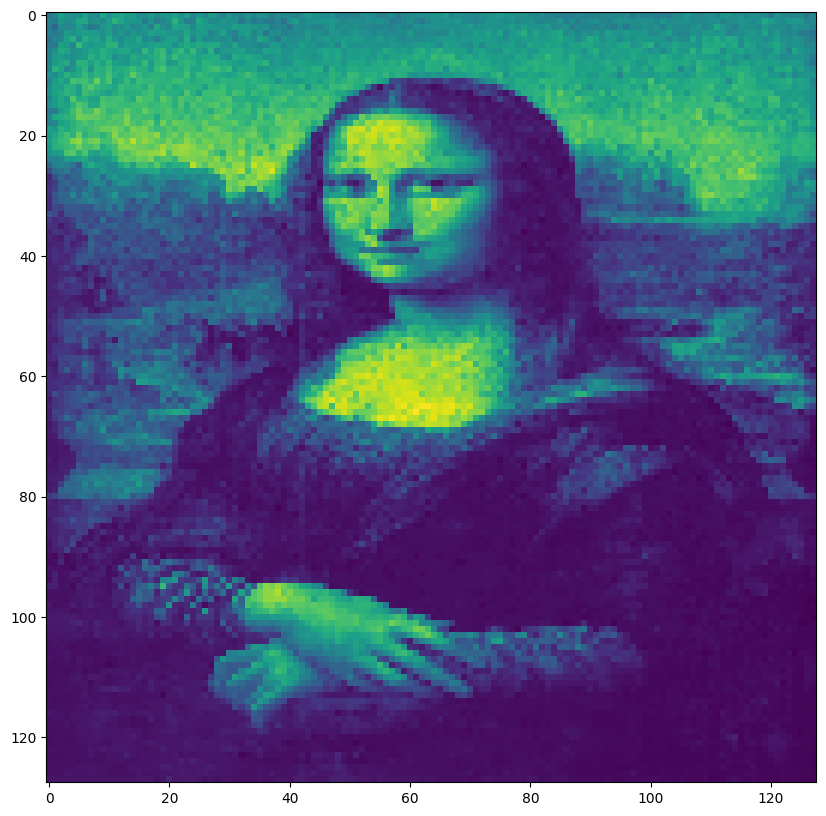

In [55]:
IMAG1 = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(10,10))
plt.imshow(IMAG1)
#IMAG = M

In [56]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 32):
                image_norm[i][j] = 9
            else:
                image_norm[i][j] = 1
    return image_norm

In [57]:
max = IMAG1.max()

In [58]:
IMAG = np.array(((IMAG1)/max)*2**3,dtype=int)+1

In [59]:
IMAG.max()

np.int64(9)

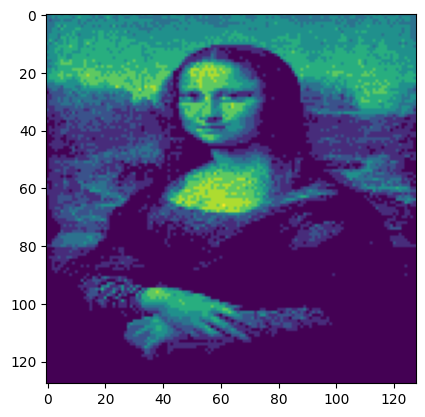

In [60]:
plt.imshow(IMAG)

In [61]:
IMAG

array([[4, 4, 5, ..., 4, 4, 4],
       [4, 4, 5, ..., 5, 4, 4],
       [4, 3, 4, ..., 5, 4, 4],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(128, 128))

In [62]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [63]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [64]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8
            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)
            k+=1
    return Mout

In [65]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget),dtype=int)
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    if(matrix.shape[0] ==1):
       # print("Kernel_transform detec")
       #Fazendo kernel**2 copias para maior deslocamneto no janelamento
        for i in range(size_row):
            for j in  range(size_row):
                matrixMout[i][j] = matrix[0][j]
                #print("Aqui",matrix[i][j])
    else:
        for i in range(size_lin):
            for j in  range(size_row):
                matrixMout[i][j] = matrix[i][j]
                #print("Aqui",matrix[i][j])
    return matrixMout
    


In [66]:
def conv2mult(sizeTarget, inputConv,inputK,debug='off'):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    if(debug=='on'):
        print("Imagem new size:",Matrix_tranform.shape)
        print("Kernel new size:",Kernel_transform.shape)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return [matrix_target_kernel,matrix_target_image]

### Kernel no domíno base

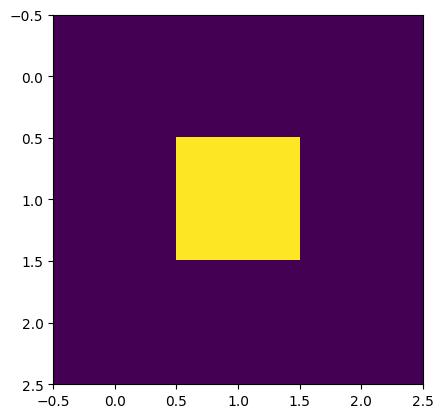

In [67]:
plt.imshow(K1)

### Imagem no domínio base

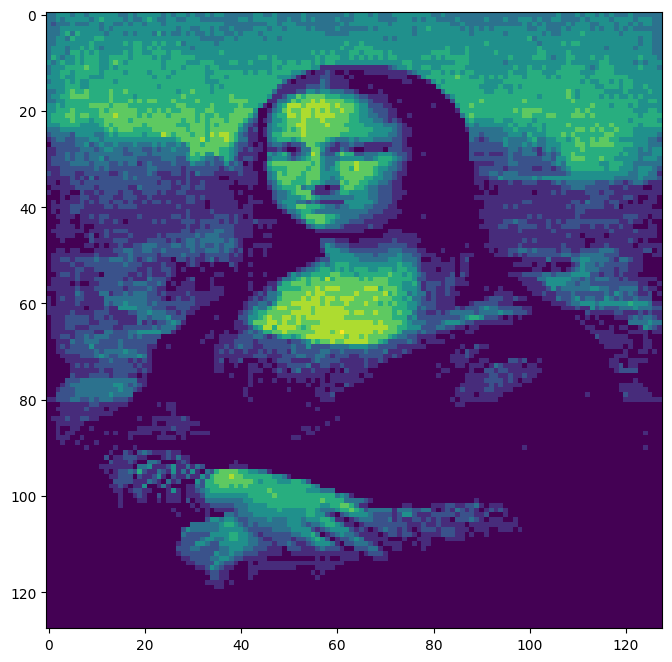

In [68]:
plt.figure(figsize=(8,8))
plt.imshow(IMAG)

In [69]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 4):
                image_norm[i][j] = 1
            else:
                image_norm[i][j] = 0
    return image_norm

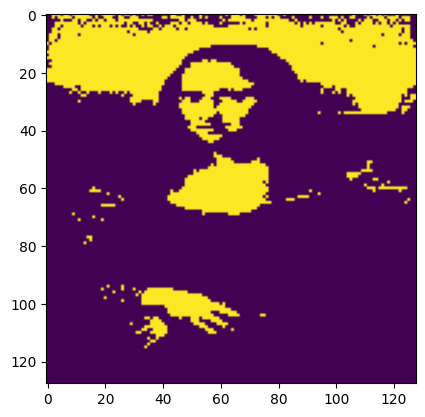

In [70]:
plt.imshow(normalizeImage(IMAG))

In [71]:
#IMAG = normalizeImage(IMAG)

In [72]:
IMAG.max()

np.int64(9)

In [73]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [74]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 16384


In [75]:
A1,B1 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K1)
A2,B2 = conv2mult(sizeTarget=requi,inputConv=IMAG,inputK=K2)

In [76]:
#A1@B1

## Kernel no novo domínio com expansão dos operandos

In [77]:
#plt.subplot(1,2,1)
#plt.imshow(A1)
#plt.subplot(1,2,2)
#plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


In [78]:
##@plt.subplot(1,2,1)
##@plt.imshow(B1)
##@plt.subplot(1,2,2)
##@plt.imshow(B2)


In [79]:
Mout_vec1 = A1
Mout_vec2 = A2

#Resultado da Convolução no novo domínio com expansão dos operandos

In [80]:
#plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
#plt.imshow(Mout_vec1)
#plt.subplot(1,2,2)
#plt.imshow(Mout_vec2)
#plt.show()

#Resultado da Convolução no domínio base

In [81]:
Mout_vec1[:][0].shape

(16384,)

In [82]:
#cmap = "gray"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout1,cmap=cmap)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap)
#plt.show()

In [83]:
#cmap1 = "gray"
#cmap2= "binary"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout2,cmap=cmap2)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap1)
#plt.show()

In [84]:
#cmap1 = "gray"
#cmap2= "gray"
#Mout1 = inv_transform(Mout_vec1,sizeMinicial = (IMAG.shape[1]-sizek+1))
#Mout2 = inv_transform(Mout_vec2,sizeMinicial = (IMAG.shape[1]-sizek+1))
#plt.figure(figsize=(15,15))
#plt.subplot(1,2,2)
#plt.imshow(Mout2+Mout1,cmap=cmap2)
#plt.subplot(1,2,1)
#plt.imshow(IMAG,cmap=cmap1)
#plt.show()

In [85]:
def windows_slice(imagem,windows_size,imag_size,step=3):

    '''Esta função retornará uma pequena fatia da imagem base, dada uma posição relativa. Com o tamanho da unidade de mulltiplicação'''
    window_buffer = np.zeros((windows_size,windows_size))
    
    try:
        for k in range(windows_size):
             for h in range(windows_size):
                window_buffer[k][h] = imagem[windows_slice.posy_static+k][windows_slice.posx_static+h]
    except:
        print("Fora do limite da imagem, posx e posy < imag_size")
        windows_slice.posx_static = 0
        windows_slice.posy_static = 0
    windows_slice.posx_static +=step
    if(windows_slice.posx_static >= imag_size-windows_size-step-1):
        windows_slice.posx_static = 0
        windows_slice.posy_static +=step
    print(windows_slice.posx_static,windows_slice.posy_static)
    return (window_buffer,windows_slice.posy_static == imag_size-windows_size-1)


In [86]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

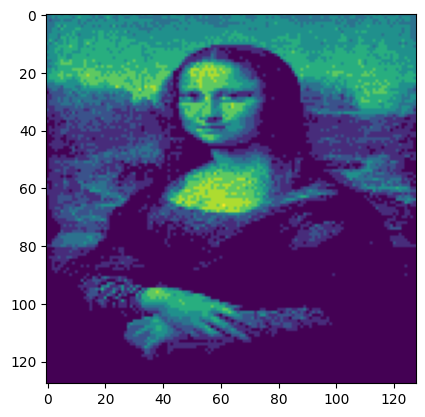

In [87]:
plt.imshow(IMAG)

In [88]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

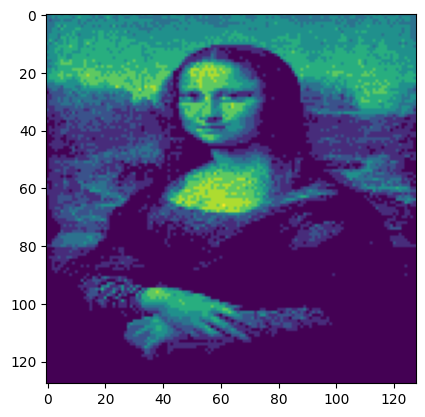

In [89]:
plt.imshow(IMAG)


In [90]:
def rebuild_image(windows_buffer_conv,size_imag,size_mult,windows_size,step=3):

    for k in range(size_mult):
     for h in range(size_mult):
        rebuild_image.window_buffer[rebuild_image.posy+k][rebuild_image.posx+h] = windows_buffer_conv[k][h]
    rebuild_image.posx +=step
    if(rebuild_image.posx >= size_imag-windows_size-step+2):
        
        if(rebuild_image.posx == size_mult and rebuild_image.posy == size_mult):
           rebuild_image.posy =size_mult
           rebuild_image.posy =size_mult
        else:   
            rebuild_image.posy +=step
            rebuild_image.posx  = 0

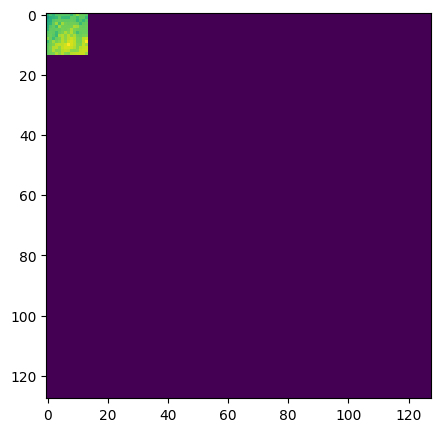

In [91]:
windows_size =16# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/30)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=256,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    break #Retire
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

In [92]:
A[1]= A[0]
A[2]= A[0]
A[3]= A[0]


In [93]:
A

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256))

# Ambiente de convolução no PC

In [94]:
K1 = np.ones((3,3))
K1[0][0] = 1
K1[1][0] = 1
K1[2][0] = 1
K1[0][2] = 1
K1[1][2] = 1
K1[2][2] = 1
K1

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

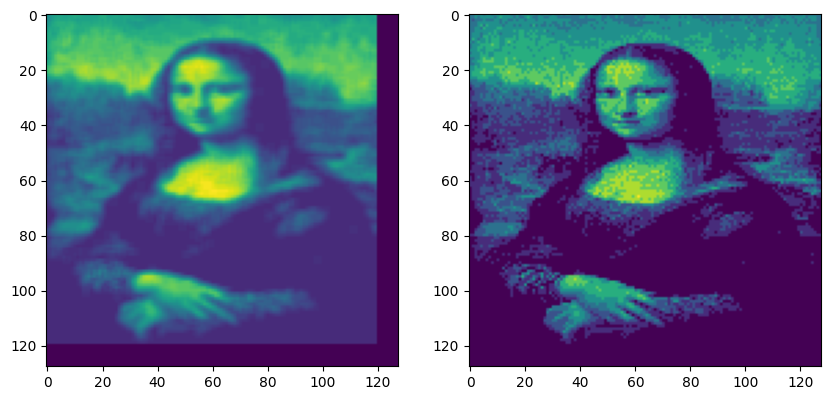

<Figure size 1000x1000 with 0 Axes>

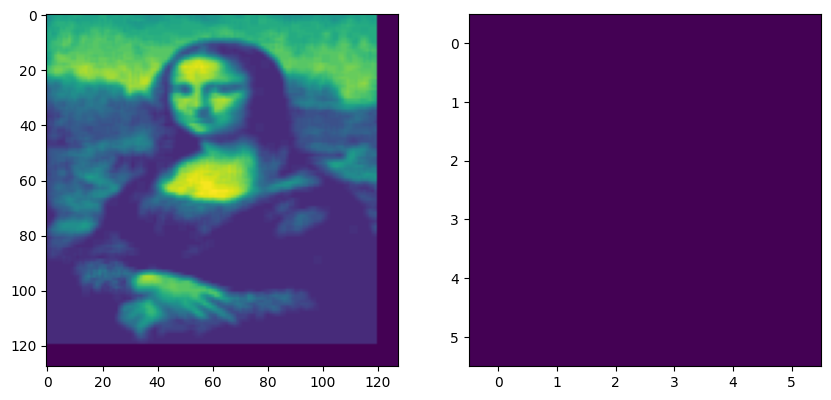

<Figure size 1000x1000 with 0 Axes>

0 120
kjhglsdgf


In [95]:
windows_size =6# Valor limite do Systolic da Arty A7
step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    if(windows_slice.posx_static >= 0 and windows_slice.posy_static > sizt-windows_size*2):
        print("kjhglsdgf")
        break
    print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
    #time.sleep(1/60)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)
    if(finish ):
        break
    sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
    A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
    Asyst=abs(A)+1#Problemas no envio do kernel com zeros
    Asyst
    Bsyst = B#normalização de 4 bits
    ResultMult = Asyst@Bsyst #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.subplot(1,2,1)
    plt.imshow(Asyst)
    plt.subplot(1,2,2)

    plt.imshow(Bsyst)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
    clear_output(wait=True)

    i+=1
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(windows_buffer)
    plt.figure(figsize=(10,10))
    plt.show()
    print(windows_slice.posx_static,windows_slice.posy_static)



# Ambiente de convolução na FPGA

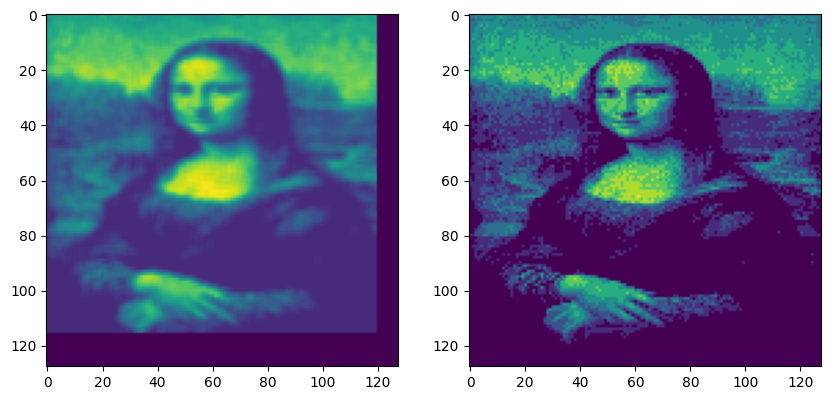

<Figure size 1000x1000 with 0 Axes>

kjhglsdgf


In [104]:
windows_size =6# Valor limite do Systolic da Arty A7
step =4#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-2*windows_size):
        print("kjhglsdgf")
        break
    print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
    #time.sleep(1/60)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)
    if(finish ):
        break
    sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
    A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
    Asyst=abs(A)+1#Problemas no envio do kernel com zeros
    Asyst
    Bsyst = B#normalização de 4 bits
    M_p = shiftMatrixSystolic(Asyst,Bsyst)


    send(M_p[0],delay = 1/fdelay,string="OPA")
    #time.sleep(2)
    send(M_p[1],delay = 1/fdelay,string="OPB")
    ResultMult = recever2(col =16,delay = 1/fdelay,string="A*B")


    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.subplot(1,2,1)
    plt.imshow(A)
    plt.subplot(1,2,2)

    plt.imshow(B)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()

In [ ]:
Asyst=abs(A)+1
Asyst
Bsyst = B//16



In [ ]:
#Asyst=abs(A)+1
#Asyst
#Bsyst = B//16
#M_p = shiftMatrixSystolic(Asyst,Bsyst)
#send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
#send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
#ResultMult = receiver_uart(size=16)
#ResultMult

b'\xfe'


KeyboardInterrupt: 

b'\xfe'


array([[165, 180, 175, 177, 171, 175, 172, 186, 173, 173, 177, 188, 179,
        190, 180, 191],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  61,  63,  65,  65,  62,  62,  64,  66,  65,
         67,  69,  71],
       [ 58,  62,  63,  64,  6

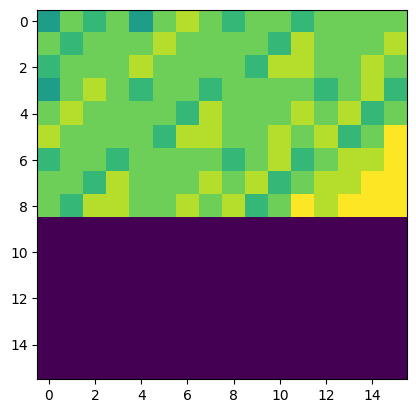

In [ ]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    bytes_enviados = 0
    bytes_recebidos = 0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        #time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)

        bytes_enviados += 2*((2*dimensao_das_matrizes-1)*dimensao_das_matrizes)*8
        bytes_recebidos += (dimensao_das_matrizes**2)*8
        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=2)
        try:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")
        except ZeroDivisionError:
            print(f"Taxa de Transferência =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos," | Bytes enviados: ",bytes_enviados/10**6,"MBytes", " |Bytes recebidos",bytes_recebidos/10**6,"MBytes")

        X =M[0]@M[1]
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        #time.sleep(((1*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        #Y = receiver_uart(dimensao_das_matrizes)
        #print_matrix(Y)
        plt.subplot(1,2,1)
        plt.title("Calculo de Referência: PC")
        plt.imshow(X)
        plt.subplot(1,2,2)
        plt.title("Calculo obtido: FPGA")
        #plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,X)
        operandos_corrompidos_cpm = compar_matrix(X,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100
#torneio(taxa_de_transferencia=baudrate,quantidade_de_op=1000,dimensao_das_matrizes=16)

----------------------------------------------------------------------------------------------------  100%
--- 3.5 %
Taxa de Transferência =  115200  3.50 / 100 | fail:  0 |Pass:  35  |Pass(%):  100.00  |Operandos Corrompidos:  0  | Bytes enviados:  0.285696 MBytes  |Bytes recebidos 0.073728 MBytes
[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 3, 2, 2, 2, 4,
        4, 2, 3, 4, 3, 2, 4, 2, 3],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 2, 4, 4, 3, 4,
        4, 4, 2, 2, 2, 2, 4, 4, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 2, 3, 4, 4, 2, 2,
        3, 2, 2, 3, 3, 4, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 2, 4, 3, 4, 3, 3, 4, 2,
        2, 4, 2, 2, 4, 4, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 4, 2, 3, 3, 4, 4, 4, 3, 2,
        2, 2, 2, 2, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 2, 4, 4, 2, 3, 4, 2, 2, 4,
        2, 3, 3, 4, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2

KeyboardInterrupt: 

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
taxa_de_transferencia = 115200
dimensao_das_matrizes = 16
while(True):
    time.sleep(1)
    #Janelamento

    #Preprocessamento das Transformações
    # ------------------------------------------------------------------------------------------------------------------------
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    #Conversão de Convolução para Multiplicação + Normalização das dimensões
    M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
    #print(A.shape)
    #plt.subplot(1,3,1)
    #plt.imshow(A)
    #plt.subplot(1,3,2)
    #plt.imshow(B)
    #plt.subplot(1,3,2)
    #plt.imshow(B)
    print(M[1].max())
    #M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
    print(M[1].max())

    #-------------------------------------------------------------------------------------------------------------------------
    # Cálculo na FPGA 
    #-------------------------------------------------------------------------------------------------------------------------
    #Preprocessamento do Systolic
    transmitter_uart(M,taxa_de_transferencia)
    ResultMult = receiver_uart(size=dimensao_das_matrizes)
    #-------------------------------------------------------------------------------------------------------------------------
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    #--------------------------------------------------------------------------------------------------------------------------
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

1 0
154
154
[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0

KeyboardInterrupt: 

<Figure size 800x800 with 0 Axes>

In [ ]:
A,B=create_matrix(16,1)
M_p = shiftMatrixSystolic(A,B)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult


b'\xfe'


array([[36, 38, 33, 39, 32, 40, 41, 30, 39, 39, 36, 38, 40, 38, 35, 42],
       [42, 45, 43, 47, 40, 49, 48, 37, 46, 48, 43, 43, 47, 45, 42, 49],
       [32, 32, 32, 35, 30, 35, 36, 27, 34, 37, 32, 31, 33, 32, 31, 36],
       [37, 37, 37, 39, 35, 41, 41, 29, 40, 42, 37, 36, 39, 39, 36, 40],
       [36, 38, 36, 38, 33, 39, 42, 29, 40, 41, 36, 37, 40, 38, 36, 40],
       [36, 36, 36, 40, 35, 41, 41, 29, 40, 42, 36, 36, 37, 39, 34, 43],
       [35, 38, 36, 38, 32, 40, 39, 31, 37, 39, 37, 35, 39, 36, 36, 39],
       [35, 38, 36, 40, 34, 40, 39, 31, 37, 41, 37, 35, 40, 38, 34, 41],
       [41, 43, 43, 44, 37, 47, 47, 36, 45, 47, 42, 41, 45, 44, 43, 46],
       [32, 33, 35, 36, 32, 37, 38, 28, 34, 38, 33, 31, 35, 35, 33, 37],
       [35, 37, 37, 41, 34, 41, 40, 31, 39, 41, 34, 35, 40, 37, 36, 40],
       [37, 42, 39, 43, 38, 44, 43, 32, 43, 43, 39, 38, 42, 41, 37, 45],
       [37, 38, 36, 41, 34, 42, 40, 29, 41, 41, 35, 37, 39, 38, 36, 41],
       [38, 42, 38, 41, 36, 45, 43, 31, 43, 42, 38,

In [ ]:
A,B=create_matrix(16,1)
M_p = shiftMatrixSystolic(A,B)
M_p[0].shape

(16, 31)

In [ ]:
M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)


In [ ]:
M[0]

array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[1])
M_p[1].shape

In [ ]:
M_p[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 101, 119, 121, 135, 112, 127, 112, 107,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 101, 119, 122, 135, 112, 126, 112, 107, 135,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        119, 122, 123, 112, 126, 127, 107, 135, 131,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 122,
        123, 118, 126, 127, 121, 135, 131, 100,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 121, 135,
        112, 127, 112, 107, 125, 121, 115,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 135, 112, 126,
        112, 107, 135, 121,

In [ ]:
(windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
windows_buffer =windows_buffer//16

2 0


In [ ]:
M = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)

In [ ]:
M

[array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[7, 6, 7, 7, 7, 8, 7, 7, 7, 7, 6, 8, 7, 7, 7, 8],
        [6, 

In [ ]:
windows_buffer

array([[7., 6., 7., 7., 7., 7.],
       [7., 8., 7., 7., 7., 7.],
       [7., 7., 6., 8., 8., 6.],
       [7., 7., 7., 8., 7., 8.],
       [7., 8., 6., 7., 9., 7.],
       [8., 8., 9., 9., 9., 9.]])

In [ ]:
M_p = shiftMatrixSystolic(windows_buffer,M[1])


In [ ]:
M_p[0]

array([[  0,   0,   0,   0,   0, 126, 101, 119, 122, 123, 118],
       [  0,   0,   0,   0, 121, 135, 112, 126, 127, 121,   0],
       [  0,   0,   0, 127, 112, 107, 135, 131, 100,   0,   0],
       [  0,   0, 125, 121, 115, 128, 118, 130,   0,   0,   0],
       [  0, 119, 128, 107, 126, 149, 127,   0,   0,   0,   0],
       [140, 143, 154, 153, 145, 150,   0,   0,   0,   0,   0]])

In [ ]:
M_p[1]

array([[  0,   0,   0,   0,   0,  89, 126, 101,  93, 121, 135,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 126, 101, 119, 121, 135, 112,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0,   0, 101, 119, 122, 135, 112, 126,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,   0, 119, 122, 123, 112, 126, 127,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [  0,  93, 121, 135, 108, 127, 112,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0],
       [121, 135, 112, 127, 112, 107,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,

In [ ]:
conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)

[array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[126, 101, 119, 122, 121, 135, 112, 126, 127, 112, 107, 135, 1

In [ ]:
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)

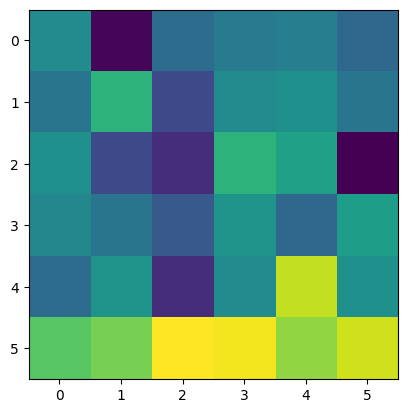

In [ ]:
plt.imshow(windows_buffer)

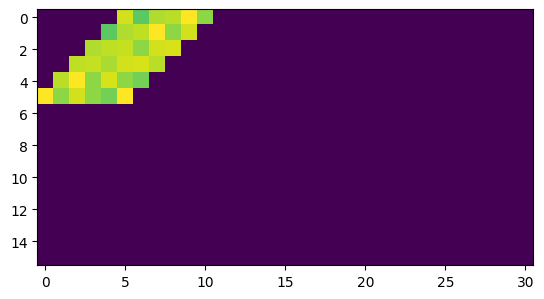

In [ ]:
plt.imshow(M_p[1])

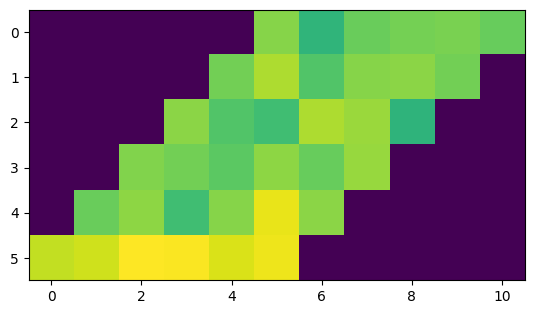

In [ ]:
plt.imshow(M_p[0])


In [ ]:
ResultMult = receiver_uart(size=dimensao_das_matrizes)
#ResultMult

b'\xfe'


KeyboardInterrupt: 

In [ ]:
M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
M

[array([[-1, -1, -1, -1,  8, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  

In [ ]:

M = conv2mult(sizeTarget=dimensao_das_matrizes,inputConv=windows_buffer,inputK=K1)
M_p = shiftMatrixSystolic(M[0],M[1])
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult

ValueError: byte must be in range(0, 256)

In [ ]:
M_p[1].max()

np.int64(7)

In [ ]:
M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate=115200)
send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate=115200)
ResultMult = receiver_uart(size=dimensao_das_matrizes)
ResultMult

b'\xfe'


KeyboardInterrupt: 

In [ ]:
windows_size =6# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/6000)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=16,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

33 1
4


KeyboardInterrupt: 

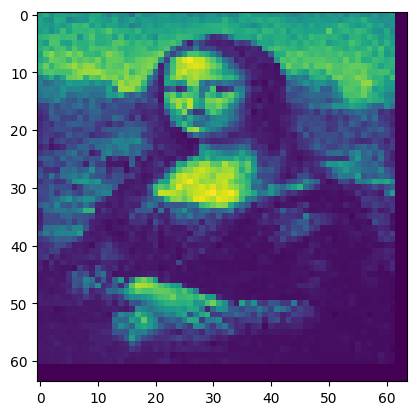

In [ ]:
plt.imshow(rebuild_image.window_buffer)